In [ ]:
import os
import json
import time
import signal
import logging
import warnings
import traceback
import numpy as np
import pandas as pd
import geopandas as gpd
from socket import gethostname
from argparse import ArgumentParser
from setproctitle import setproctitle
from nd2.model import NDformer
from nd2.utils import init_logger, AutoGPU, seed_all
from nd2.search import MCTS
from nd2.GDExpr import GDExpr
from nd2.search.reward_solver import RewardSolver

In [134]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.animation import FuncAnimation
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from nd2.utils.plot import get_fig


def farthest_point_sampling(pos, k, seed=None):
    """
    从 pos 中选择 k 个点，使两两之间的最小距离尽可能大（近似）
    pos: dict 或 (N,2) ndarray —— 节点坐标
    k: 需要采样的点数
    """
    rng = np.random.default_rng(seed)

    if isinstance(pos, dict):
        keys = np.array(list(pos.keys()))
        coords = np.array([pos[i] for i in keys])
    elif isinstance(pos, pd.Series):
        keys = pos.index.to_numpy()
        coords = np.array(pos.to_list())
    else:
        coords = np.asarray(pos)
        keys = np.arange(len(coords))

    N = len(coords)
    if k >= N:
        return list(keys)

    # 随机选第一个点
    first = rng.integers(0, N)
    chosen = [first]
    # 记录每个点到已选点集的最近距离
    dist = np.linalg.norm(coords - coords[first], axis=1)

    for _ in range(1, k):
        # 选择距离已选点集最远的点
        idx = np.argmax(dist)
        chosen.append(idx)
        # 更新每个点到已选集的最小距离
        dist = np.minimum(dist, np.linalg.norm(coords - coords[idx], axis=1))

    return [keys[i] for i in chosen]

def animate_graph_with_traces(
        A, X, 
        node_labels=None, 
        time_labels=None,
        k_sample=4,
        trace_window=30, 
        interval=200, 
        save_path=None,
        ax=None, 
        pos=None,
        inset_axes_size=0.2,
        node_size_min=100,
        node_size_max=500,
        animate=True,
        random_state=42,
    ):
    """
    A: NxN 邻接矩阵
    X: NxT 节点活动矩阵
    """
    N, T = X.shape
    G = nx.from_numpy_array(A)
    if pos is None:
        # pos = nx.spring_layout(G, seed=42)
        pos = nx.kamada_kawai_layout(G)
    cmap = cm.get_cmap('plasma')
    norm = lambda v: (v - X.min()) / (X.max() - X.min() + 1e-9)

    if ax is None:
        fi, fig, axes = get_fig(1, 1, AW=15, AH=15, dpi=300)
        ax = axes[0]
        # ax.axis('off')
    else:
        fig = ax.figure

    # 初始绘制节点和边
    edges = [(u, v) for u, v in G.edges() if A[u, v] > 0]
    nx.draw_networkx_edges(G, pos, ax=ax, width=0.5, alpha=0.4)
    nodes_scatter = ax.scatter(
        [pos[i][0] for i in range(N)],
        [pos[i][1] for i in range(N)],
        s=(node_size_min+node_size_max)/2, c='gray', edgecolors='k', zorder=3
    )
    labels = node_labels or {i: str(i) for i in range(N)}
    for i, (x, y) in pos.items():
        ax.text(x, y, labels[i], fontsize=8, ha='center', va='center', zorder=4)

    # === 采样一些距离远的节点 ===
    sampled_nodes = farthest_point_sampling(pos, k=k_sample, seed=random_state)
    print("Sampled nodes:", sampled_nodes)

    # 为每个节点添加小 inset axes
    insets = {}
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    x_range = xmax - xmin
    y_range = ymax - ymin
    for n in sampled_nodes:
        # 节点位置
        x, y = pos[n]
        ax_inset = inset_axes(
            ax, 
            width="100%", height="100%",
            bbox_to_anchor=(x, y, inset_axes_size * x_range, inset_axes_size * y_range),
            bbox_transform=ax.transData,
            loc='center'
        )
        ax_inset.set_facecolor((0.95, 0.95, 0.95))
        ax_inset.set_xlim(0, trace_window)
        ax_inset.set_ylim(X.min(), X.max())
        ax_inset.tick_params(labelsize=6, length=2)
        ax_inset.set_xticks([])
        ax_inset.set_yticks([])
        insets[n] = ax_inset

    # 初始化每个 inset 的折线对象
    trace_lines = {}
    for n in sampled_nodes:
        (line,) = insets[n].plot([], [], lw=1.0, color='tab:red')
        trace_lines[n] = line

    title = ax.text(0.5, 1.02, "", transform=ax.transAxes,
                    ha='center', va='bottom', fontsize=10)

    def update(frame):
        # 更新主节点可视化
        vals = X[:, frame]
        colors = cmap(norm(vals))
        nodes_scatter.set_color(colors)
        nodes_scatter.set_sizes(node_size_min + (node_size_max - node_size_min) * norm(vals))
        if time_labels is None:
            title.set_text(f"t = {frame}")
        else:
            title.set_text(f"{time_labels[frame]}")

        # 更新小轨迹图
        for n in sampled_nodes:
            # start = max(0, frame - trace_window)
            # x_data = np.arange(frame - start)
            # y_data = X[n, start:frame]
            # trace_lines[n].set_data(x_data, y_data)
            # 动态调整 x 轴
            # insets[n].set_xlim(0, trace_window)
            # insets[n].set_ylim(X.min(), X.max())
            trace_lines[n].set_data(np.arange(frame), X[n, :frame])
            insets[n].set_xlim(0, frame)
            insets[n].set_ylim(X.min(), X.max())
        return [nodes_scatter, title] + list(trace_lines.values())

    if not animate:
        return

    anim = FuncAnimation(fig, update, frames=T, interval=interval, blit=False)

    if save_path:
        # anim.save(save_path, writer="pillow", fps=1000 / interval)
        anim.save(save_path, writer="ffmpeg", fps=1000 / interval)
        print(f"Saved to {save_path}")

    plt.show()
    return anim


Sampled nodes: [np.int64(23), np.int64(50), np.int64(172), np.int64(111), np.int64(131), np.int64(45), np.int64(94)]
Saved to playground/NYC-demo.mp4


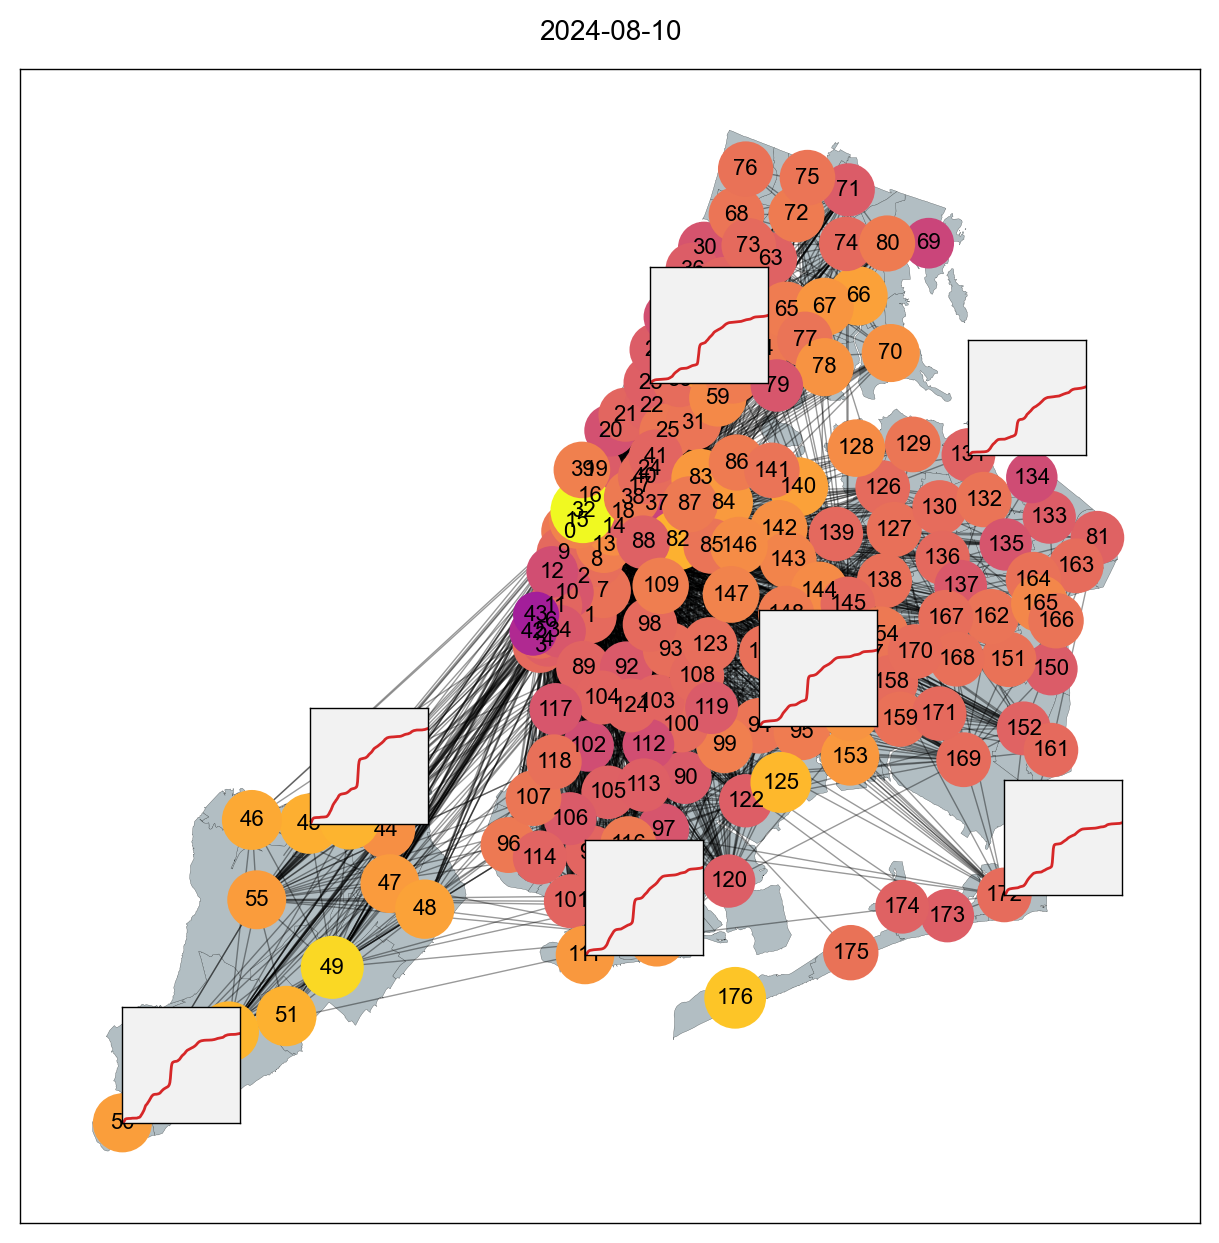

In [135]:
# %% Load Data
data = json.load(open(f'./data/epidemic/COVID19inNYC.json'))
A = np.array(data['A']) # (N, N)
case = np.array(data['case'], dtype=np.float32).T # (N, T)

fi, fig, axes = get_fig(1, 1, AW=15, AH=15, dpi=200, LM=5, TM=5, BM=5, RM=5)
ax = axes[0]

gdf = gpd.read_file('./data/epidemic/MODZCTA_2010.shp')[["MODZCTA", "geometry"]]
gdf = gdf[gdf['MODZCTA'] != '99999']
tract_gdf = gpd.read_file('./data/epidemic/tl_2020_36_tract.zip')[["GEOID", "geometry"]]
gdf = gdf.to_crs(tract_gdf.crs)
gdf = gdf[['MODZCTA', 'geometry']].set_index('MODZCTA')
gdf.plot(color='#b2bec3', edgecolor='#2d3436', linewidth=0.1, ax=ax)

animate_graph_with_traces(
    A, 
    np.cumsum(case, axis=1), 
    time_labels=data['time'],
    k_sample=7,
    trace_window=30,
    interval=50,
    save_path="playground/NYC-demo.mp4",
    pos={idx: gdf.loc[node, 'geometry'].centroid.coords[0] for idx, node in enumerate(data['node'])},
    inset_axes_size=0.1,
    ax=ax,
    animate=True,
    random_state=48,
)

C:\Users\YuMeow\AppData\Local\Temp\ipykernel_47844\2344289852.py:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma')


Sampled nodes: [np.int64(5), np.int64(51), np.int64(9), np.int64(6), np.int64(0), np.int64(36), np.int64(35)]


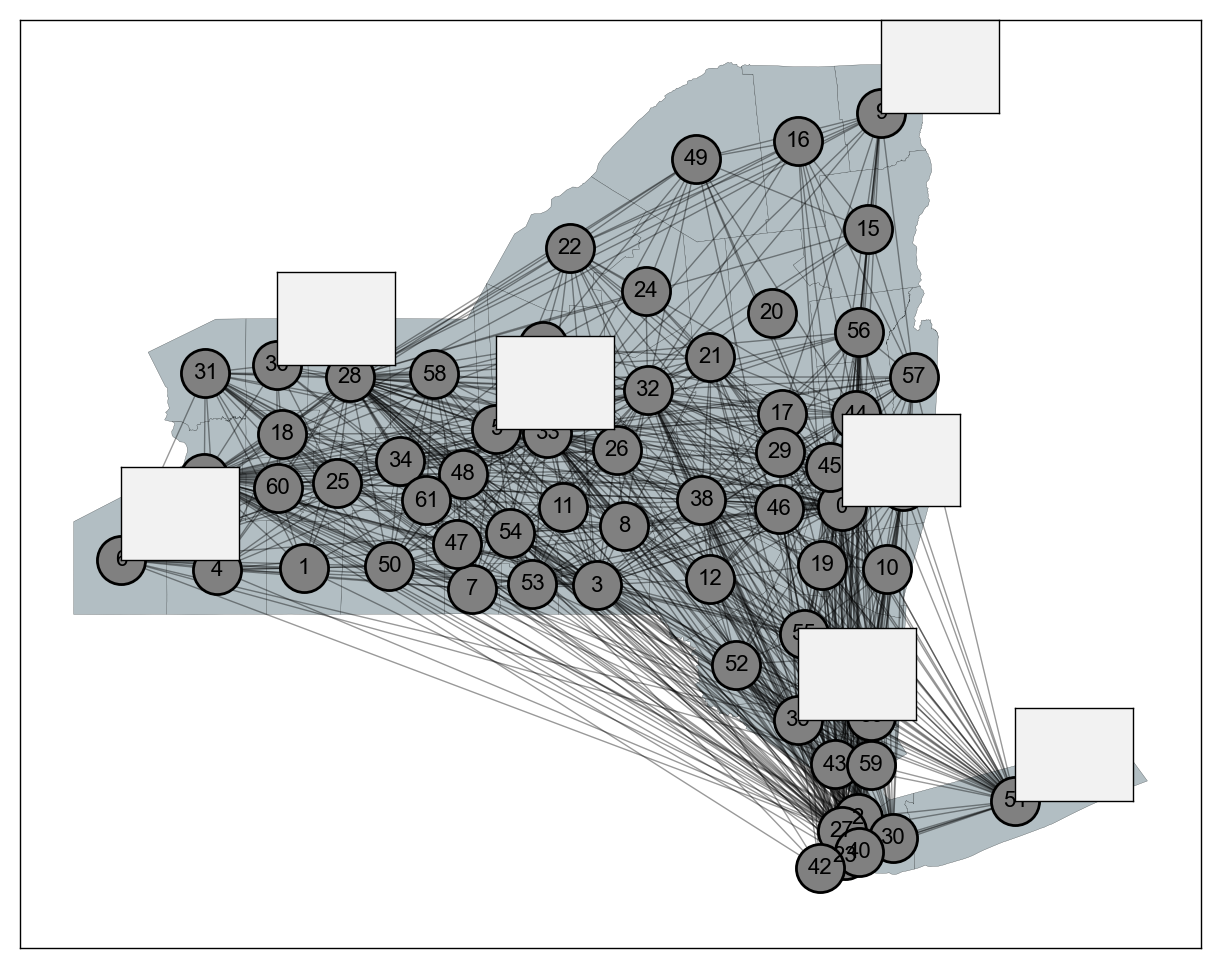

In [93]:
# %% Load Data
data = json.load(open(f'./data/epidemic/COVID19inNYS.json'))
case = np.array(data['case'], dtype=np.float32)
# population = np.array(data['population'], dtype=np.float32)
flow = np.array(data['flow'], dtype=np.float32)[np.newaxis, :].repeat(case.shape[0]-1, axis=0)
A = np.array(data['A'])
G = np.array(data['G'])
y = case[1:].copy()
X7 = case[:-1].copy()
X14 = case[:-1].copy(); X14[1:] += case[:-2]
# P = population.copy()
F = flow.copy()

gdf = gpd.read_file('./data/epidemic/kx-new-york-state-counties-SHP.zip')
gdf['NAME'] = gdf['NAME'].replace({'St Lawrence': 'St. Lawrence', 'New York': 'Manhattan'})
gdf = gdf.set_index('NAME')

fi, fig, axes = get_fig(1, 1, AW=15, AH=15, dpi=200, LM=5, TM=5, BM=5, RM=5)
ax = axes[0]

gdf.plot(color='#b2bec3', edgecolor='#2d3436', linewidth=0.1, ax=ax)
animate_graph_with_traces(
    A, np.cumsum(case.T, axis=1), 
    time_labels=data['time'],
    k_sample=7,
    trace_window=30,
    interval=50,
    save_path="playground/NYS-demo.mp4",
    pos={idx: gdf.loc[node, 'geometry'].centroid.coords[0] for idx, node in enumerate(data['node'])},
    inset_axes_size=0.1,
    ax=ax,
    animate=False,
    random_state=42,
)

Sampled nodes: [np.int64(6), np.int64(11), np.int64(47), np.int64(1), np.int64(43), np.int64(9), np.int64(49)]
Saved to playground/US-demo.mp4


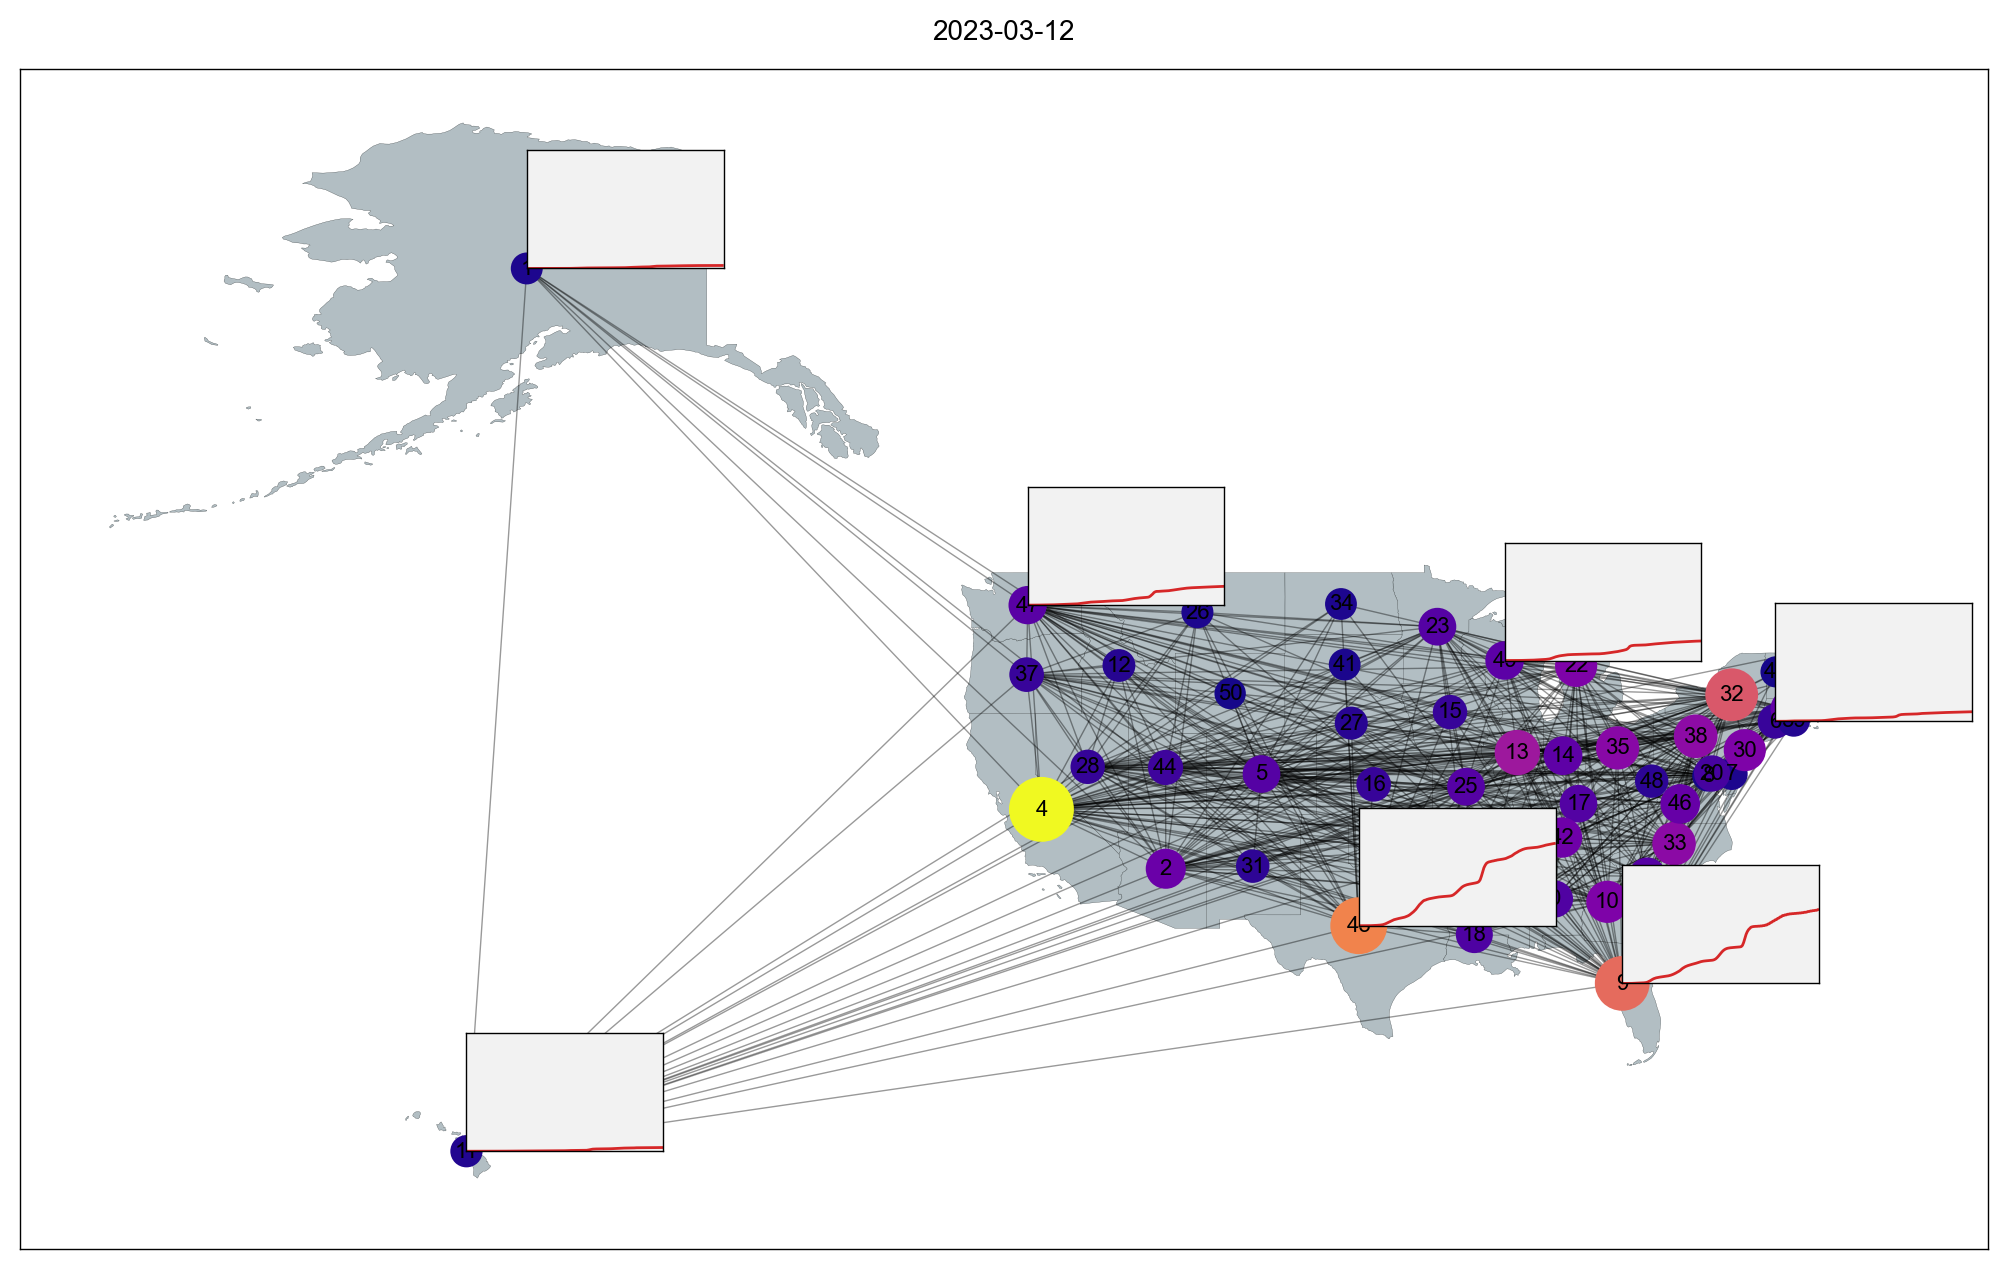

In [125]:
# %% Load Data
data = json.load(open(f'./data/epidemic/COVID19inUS.json'))
case = np.array(data['case'], dtype=np.float32)
# population = np.array(data['population'], dtype=np.float32)
flow = np.array(data['flow'], dtype=np.float32)[np.newaxis, :].repeat(case.shape[0]-1, axis=0)
A = np.array(data['A'])
G = np.array(data['G'])
y = case[1:].copy()
X7 = case[:-1].copy()
X14 = case[:-1].copy(); X14[1:] += case[:-2]
# P = population.copy()
F = flow.copy()

gdf = gpd.read_file('./data/epidemic/cb_2022_us_state_20m.zip')
gdf = gdf[gdf['NAME'].isin(data['node'])]
gdf = gdf.set_index('NAME')[['geometry']]
# gdf = gdf[gdf.index.isin(data['node'])]
from shapely.geometry import box
gdf["geometry"] = gdf["geometry"].apply(lambda x: x.intersection(box(-180, -90, 0, 90)))

fi, fig, axes = get_fig(1, 1, AW=25, AH=15, dpi=200, LM=5, TM=5, BM=5, RM=5)
ax = axes[0]
gdf.plot(color='#b2bec3', edgecolor='#2d3436', linewidth=0.1, ax=ax)
# ax.set_aspect('auto')
# ax.set_xlim(-180, -60)
# ax.set_ylim(15, 75)
# ax.axis('off')
animate_graph_with_traces(
    A, np.cumsum(case.T, axis=1), 
    time_labels=data['time'],
    k_sample=7,
    trace_window=30,
    interval=50,
    save_path="playground/US-demo.mp4",
    pos={idx: gdf.loc[node, 'geometry'].centroid.coords[0] for idx, node in enumerate(data['node'])},
    inset_axes_size=0.1,
    ax=ax,
    animate=True,
    random_state=48,
)

Sampled nodes: [np.int64(24), np.int64(123), np.int64(177), np.int64(182), np.int64(89), np.int64(96), np.int64(161)]
Saved to playground/World-demo.mp4


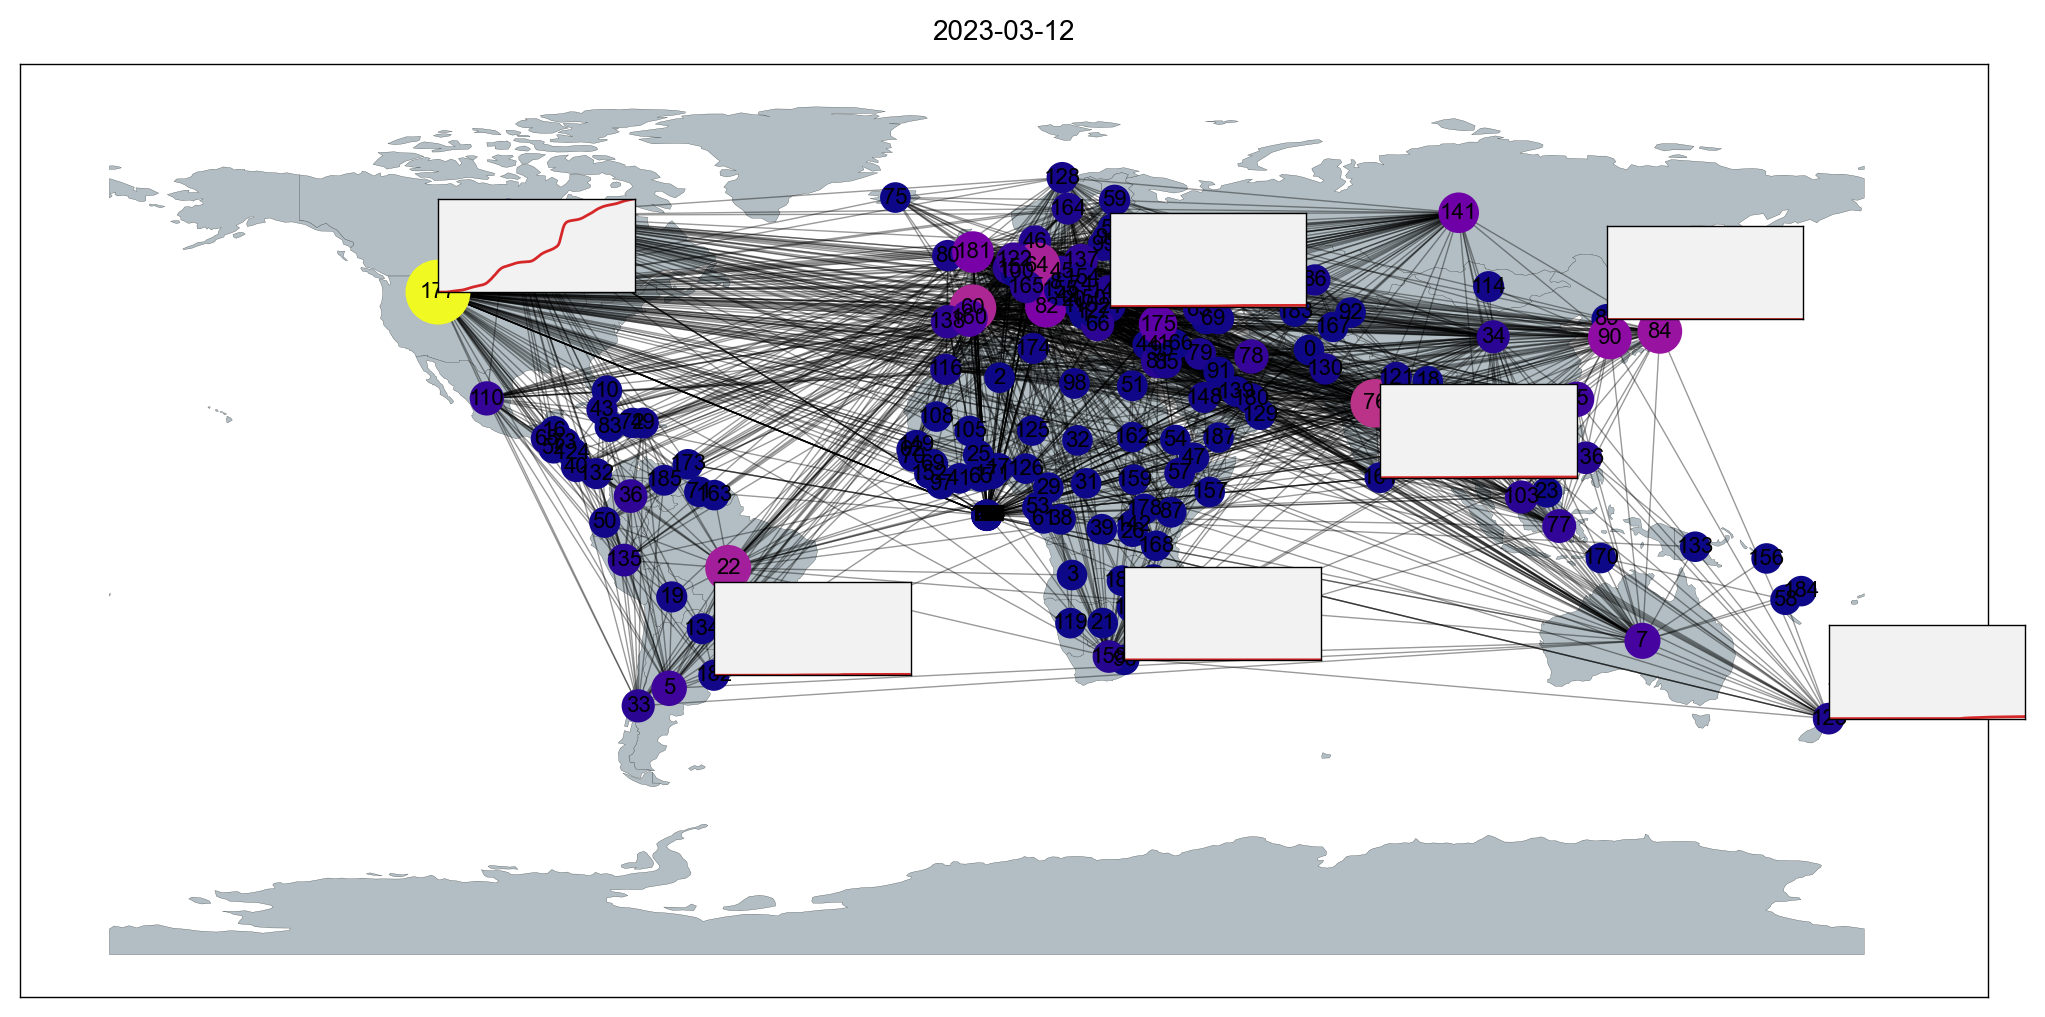

In [133]:
# %% Load Data
data = json.load(open(f'./data/epidemic/COVID19inWorld.json'))
case = np.array(data['case'], dtype=np.float32)
# population = np.array(data['population'], dtype=np.float32)
flow = np.array(data['flow'], dtype=np.float32)[np.newaxis, :].repeat(case.shape[0]-1, axis=0)
A = np.array(data['A'])
G = np.array(data['G'])
y = case[1:].copy()
X7 = case[:-1].copy()
X14 = case[:-1].copy(); X14[1:] += case[:-2]
F = flow.copy()

gdf = gpd.read_file('./data/epidemic/ne_110m_admin_0_countries.zip')
gdf['NAME'] = gdf['NAME'].replace({'United States of America': 'US', 'South Korea': 'Korea, South', 'North Korea': 'Korea, North', 'Republic of Serbia': 'Serbia', 'Congo': 'Congo (Brazzaville)', 'Dem. Rep. Congo': 'Congo (Kinshasa)', 'United Republic of Tanzania': 'Tanzania', 'eSwatini': 'Eswatini', 'The Bahamas': 'Bahamas', 'Taiwan': 'Chinese Taipei', 'S. Sudan': 'South Sudan', 'Dominican Rep.': 'Dominican Republic', 'Eq. Guinea': 'Equatorial Guinea', 'Bosnia and Herz.': 'Bosnia and Herzegovina', "Côte d'Ivoire": "Cote d'Ivoire", 'Solomon Is.': 'Solomon Islands', 'Central African Rep.': 'Central African Republic'})
gdf = gdf.set_index('NAME')[['geometry']]

fi, fig, axes = get_fig(1, 1, AW=25, AH=15, dpi=200, LM=5, TM=5, BM=5, RM=5)
ax = axes[0]
gdf.plot(color='#b2bec3', edgecolor='#2d3436', linewidth=0.1, ax=ax)
animate_graph_with_traces(
    A, np.cumsum(case.T, axis=1), 
    time_labels=data['time'],
    k_sample=7,
    trace_window=30,
    interval=50,
    save_path="playground/World-demo.mp4",
    pos={idx: gdf.loc[node, 'geometry'].centroid.coords[0] if node in gdf.index else (0, 0) for idx, node in enumerate(data['node'])},
    inset_axes_size=0.1,
    ax=ax,
    animate=True,
    random_state=48,
)

In [ ]:
# %% Load Data
data = json.load(open(f'./data/epidemic/COVID19inCHI.json'))
case = np.array(data['case'], dtype=np.float32)
# population = np.array(data['population'], dtype=np.float32)
flow = np.array(data['flow'], dtype=np.float32)[np.newaxis, :].repeat(case.shape[0]-1, axis=0)
A = np.array(data['A'])
G = np.array(data['G'])
y = case[1:].copy()
X7 = case[:-1].copy()
X14 = case[:-1].copy(); X14[1:] += case[:-2]
# P = population.copy()
F = flow.copy()
from shapely.ops import unary_union

df = pd.read_csv('./data/epidemic/zip2tract2020.csv', names=['ZIPCode', 'St', 'StCity', 'Tract', 'TractGeoID', 'CtyName', 'ZIPName', 'Pop 2020', 'Part Pct'], encoding='latin1')
df['ZIPCode'] = df['ZIPCode'].astype(str)
df['TractGeoID'] = df['TractGeoID'].astype(str)
tract2zip = {}
for tract, group in df.groupby('TractGeoID'):
    idx = group['Part Pct'].argmax()
    tract2zip[tract] = group.iloc[idx]['ZIPCode']

gdf = gpd.read_file('./data/epidemic/Boundaries - Census Tracts - 2010.zip')
gdf['zipcode'] = gdf['geoid10'].map(tract2zip).fillna('Unknown')
coor = [(zipcode, unary_union(group['geometry'])) for zipcode, group in gdf.groupby('zipcode')]
gdf = gpd.GeoDataFrame(coor, columns=['NAME', 'geometry'], crs=gdf.crs).set_index('NAME')
fi, fig, axes = get_fig(1, 1, AW=15, AH=15, dpi=100, LM=5, TM=5, BM=5, RM=5)
ax = axes[0]

gdf.plot(color='#b2bec3', edgecolor='#2d3436', linewidth=0.1, ax=ax)
nan = np.array(gdf['geometry'].apply(lambda g: g.centroid.coords[0]).tolist()).mean(axis=0)
animate_graph_with_traces(
    A, np.cumsum(case.T, axis=1), 
    time_labels=data['time'],
    k_sample=7,
    trace_window=30,
    interval=50,
    save_path="playground/CHI-demo.mp4",
    pos={idx: gdf.loc[node, 'geometry'].centroid.coords[0] if node in gdf.index else nan for idx, node in enumerate(data['node'])},
    inset_axes_size=0.1,
    ax=ax,
    animate=True,
    random_state=48,
)

Sampled nodes: [np.int64(13), np.int64(49), np.int64(80), np.int64(91), np.int64(74), np.int64(48), np.int64(34)]
Saved to ILS-demo.mp4


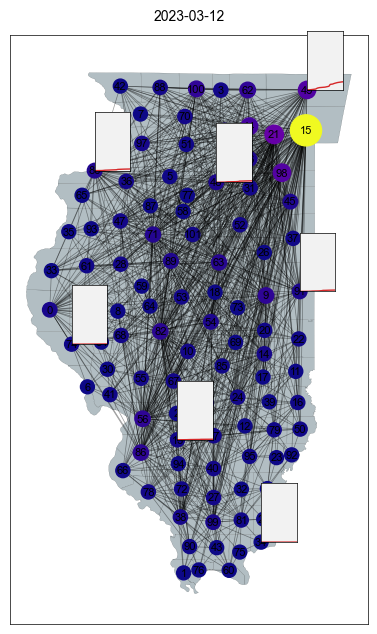

In [ ]:
# %% Load Data
data = json.load(open(f'./data/epidemic/COVID19inILS.json'))
case = np.array(data['case'], dtype=np.float32)
# population = np.array(data['population'], dtype=np.float32)
flow = np.array(data['flow'], dtype=np.float32)[np.newaxis, :].repeat(case.shape[0]-1, axis=0)
A = np.array(data['A'])
G = np.array(data['G'])
y = case[1:].copy()
X7 = case[:-1].copy()
X14 = case[:-1].copy(); X14[1:] += case[:-2]
# P = population.copy()
F = flow.copy()
from shapely.ops import unary_union

gdf = gpd.read_file('./data/epidemic/tl_2016_17_cousub.zip')
GEOID2Name = {17001: "Adams", 17003: "Alexander", 17005: "Bond", 17007: "Boone", 17009: "Brown", 17011: "Bureau", 17013: "Calhoun", 17015: "Carroll", 17017: "Cass", 17019: "Champaign", 17021: "Christian", 17023: "Clark", 17025: "Clay", 17027: "Clinton", 17029: "Coles", 17031: "Cook", 17033: "Crawford", 17035: "Cumberland", 17037: "DeKalb", 17039: "De Witt", 17041: "Douglas", 17043: "DuPage", 17045: "Edgar", 17047: "Edwards", 17049: "Effingham", 17051: "Fayette", 17053: "Ford", 17055: "Franklin", 17057: "Fulton", 17059: "Gallatin", 17061: "Greene", 17063: "Grundy", 17065: "Hamilton", 17067: "Hancock", 17069: "Hardin", 17071: "Henderson", 17073: "Henry", 17075: "Iroquois", 17077: "Jackson", 17079: "Jasper", 17081: "Jefferson", 17083: "Jersey", 17085: "Jo Daviess", 17087: "Johnson", 17089: "Kane", 17091: "Kankakee", 17093: "Kendall", 17095: "Knox", 17097: "Lake", 17099: "LaSalle", 17101: "Lawrence", 17103: "Lee", 17105: "Livingston", 17107: "Logan", 17109: "McDonough", 17111: "McHenry", 17113: "McLean", 17115: "Macon", 17117: "Macoupin", 17119: "Madison", 17121: "Marion", 17123: "Marshall", 17125: "Mason", 17127: "Massac", 17129: "Menard", 17131: "Mercer", 17133: "Monroe", 17135: "Montgomery", 17137: "Morgan", 17139: "Moultrie", 17141: "Ogle", 17143: "Peoria", 17145: "Perry", 17147: "Piatt", 17149: "Pike", 17151: "Pope", 17153: "Pulaski", 17155: "Putnam", 17157: "Randolph", 17159: "Richland", 17161: "Rock Island", 17163: "St. Clair", 17165: "Saline", 17167: "Sangamon", 17169: "Schuyler", 17171: "Scott", 17173: "Shelby", 17175: "Stark", 17177: "Stephenson", 17179: "Tazewell", 17181: "Union", 17183: "Vermilion", 17185: "Wabash", 17187: "Warren", 17189: "Washington", 17191: "Wayne", 17193: "White", 17195: "Whiteside", 17197: "Will", 17199: "Williamson", 17201: "Winnebago", 17203: "Woodford"}
tmp = []
for (state_fp, county_fp), group in gdf.groupby(['STATEFP', 'COUNTYFP']):
    name = GEOID2Name[int(state_fp + county_fp)]
    polygon = unary_union(group['geometry'])
    tmp.append((name, polygon))
gdf = gpd.GeoDataFrame(tmp, columns=['NAME', 'geometry'], crs=gdf.crs)
gdf = gdf.set_index('NAME')

fi, fig, axes = get_fig(1, 1, AW=15, AH=15, dpi=100, LM=5, TM=5, BM=5, RM=5)
ax = axes[0]

gdf.plot(color='#b2bec3', edgecolor='#2d3436', linewidth=0.1, ax=ax)
nan = np.array(gdf['geometry'].apply(lambda g: g.centroid.coords[0]).tolist()).mean(axis=0)
animate_graph_with_traces(
    A, np.cumsum(case.T, axis=1), 
    time_labels=data['time'],
    k_sample=7,
    trace_window=30,
    interval=50,
    save_path="playground/ILS-demo.mp4",
    pos={idx: gdf.loc[node, 'geometry'].centroid.coords[0] if node in gdf.index else nan for idx, node in enumerate(data['node'])},
    inset_axes_size=0.1,
    ax=ax,
    animate=True,
    random_state=48,
)

Sampled nodes: [np.int64(4), np.int64(28), np.int64(10), np.int64(24), np.int64(32), np.int64(31), np.int64(8)]
Saved to playground/CN-demo.mp4


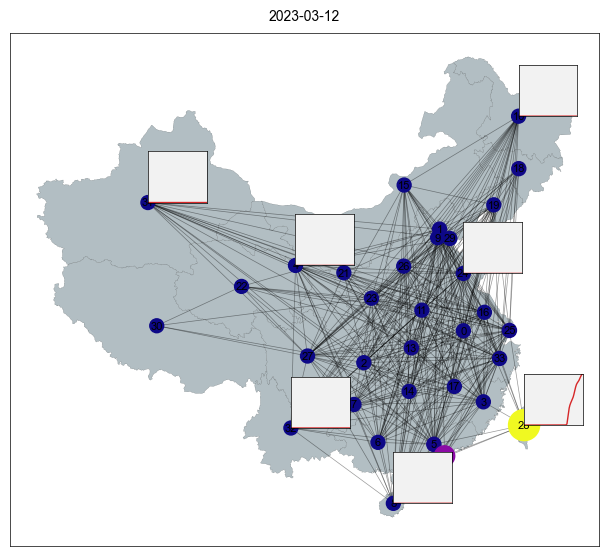

In [155]:
# %% Load Data
data = json.load(open(f'./data/epidemic/COVID19inCN.json'))
case = np.array(data['case'], dtype=np.float32)
# population = np.array(data['population'], dtype=np.float32)
flow = np.array(data['flow'], dtype=np.float32)[np.newaxis, :].repeat(case.shape[0]-1, axis=0)
A = np.array(data['A'])
G = np.array(data['G'])
y = case[1:].copy()
X7 = case[:-1].copy()
X14 = case[:-1].copy(); X14[1:] += case[:-2]
# P = population.copy()
F = flow.copy()
from shapely.ops import unary_union

gdf = gpd.read_file('./data/epidemic/Province')
mapping = {'黑龙江': 'Heilongjiang', '新疆': 'Xinjiang', '山西': 'Shanxi', '宁夏': 'Ningxia', '西藏': 'Tibet', '山东': 'Shandong', '河南': 'Henan', '江苏': 'Jiangsu', '安徽': 'Anhui', '湖北': 'Hubei', '浙江': 'Zhejiang', '江西': 'Jiangxi', '湖南': 'Hunan', '云南': 'Yunnan', '贵州': 'Guizhou', '福建': 'Fujian', '广西': 'Guangxi', '广东': 'Guangdong', '海南': 'Hainan', '吉林': 'Jilin', '辽宁': 'Liaoning', '天津': 'Tianjin', '青海': 'Qinghai', '甘肃': 'Gansu', '陕西': 'Shaanxi', '内蒙古': 'Inner Mongolia', '重庆': 'Chongqing', '河北': 'Hebei', '上海': 'Shanghai', '北京': 'Beijing', '台湾': 'Taiwan', '香港': 'Hong Kong', '澳门': 'Macau', '四川': 'Sichuan'}
gdf['NAME'] = gdf['NAME'].replace(mapping)
gdf = gdf.set_index('NAME')

fi, fig, axes = get_fig(1, 1, AW=15, AH=15, dpi=100, LM=5, TM=5, BM=5, RM=5)
ax = axes[0]

gdf.plot(color='#b2bec3', edgecolor='#2d3436', linewidth=0.1, ax=ax)
nan = np.array(gdf['geometry'].apply(lambda g: g.centroid.coords[0]).tolist()).mean(axis=0)
animate_graph_with_traces(
    A, np.cumsum(case.T, axis=1), 
    time_labels=data['time'],
    k_sample=7,
    trace_window=30,
    interval=50,
    save_path="playground/CN-demo.mp4",
    pos={idx: gdf.loc[node, 'geometry'].centroid.coords[0] if node in gdf.index else nan for idx, node in enumerate(data['node'])},
    inset_axes_size=0.1,
    ax=ax,
    animate=True,
    random_state=48,
)